In [1]:
import pandas as pd
import numpy as np

# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_csv("hf://datasets/openadmet/openadmet-expansionrx-challenge-train-data/expansion_data_train.csv")

In [2]:
df.to_csv("raw_datasets/expansion/expansion_data_train.csv")

In [3]:
df

,Molecule Name,SMILES,LogD,KSOL,HLM CLint,MLM CLint,Caco-2 Permeability Papp A>B,Caco-2 Permeability Efflux,MPPB,MBPB,MGMB
0,E-0001321,CN1CCC[C@H]1COc1ccc(-c2nc3cc(-c4ccc5[nH]c(-c6c...,NaN,NaN,56.4,182.3,NaN,NaN,NaN,NaN,NaN
1,E-0001780,COc1ccc2c(c1)c1cc3cnccc3c(C)c1n2C,NaN,NaN,160.4,1351.1,NaN,NaN,NaN,NaN,NaN
2,E-0001827,Cc1c2ccncc2cc2c3cc(OCCCN4CCN(C)CC4)ccc3n(C)c12,NaN,NaN,NaN,193.5,NaN,NaN,NaN,NaN,NaN
3,E-0002019,CN(C)CCCOc1ccc(-c2nc3cc(NC(=O)c4ccc5[nH]c(-c6c...,NaN,NaN,9.5,NaN,NaN,NaN,NaN,NaN,NaN
4,E-0002036,CN(C)CCCOc1ccc2nc(-c3ccc(-c4nc5ccc(OCCCN(C)C)c...,NaN,NaN,NaN,162.0,NaN,NaN,NaN,NaN,0.0122
...,...,...,...,...,...,...,...,...,...,...,...
5321,E-0020096,CCn1c(C(=O)N2CCN(c3ccncc3)CC2)cc2cc(-c3nnc(C4C...,2.5,257.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5322,E-0020097,Cc1nnc(-c2cnc3c(c2)cc(C(=O)N2CCCN(c4ccncc4C)CC...,1.5,277.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5323,E-0020098,Cc1nnc(-c2ccc3c(c2)cc(C(=O)N2CCCN(c4ccncc4)CC2...,1.0,273.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5324,E-0020099,Cc1nnc(-c2ccc3c(c2)cc(C(=O)N2CCCN(c4ccncc4C)CC...,2.2,273.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_remove = df[["Molecule Name", "SMILES", "HLM CLint"]].dropna().reset_index(drop=True)

In [5]:
df_remove

,Molecule Name,SMILES,HLM CLint
0,E-0001321,CN1CCC[C@H]1COc1ccc(-c2nc3cc(-c4ccc5[nH]c(-c6c...,56.4
1,E-0001780,COc1ccc2c(c1)c1cc3cnccc3c(C)c1n2C,160.4
2,E-0002019,CN(C)CCCOc1ccc(-c2nc3cc(NC(=O)c4ccc5[nH]c(-c6c...,9.5
3,E-0002269,CN(C)CC(O)COc1ccc2nc(-c3ccc(-c4nc5ccc(OCC(O)CN...,18.9
4,E-0002284,COc1ccc(-c2nc3ccc(OCCCN(C)C)cc3[nH]2)cc1NC(=O)...,14.9
...,...,...,...
3754,E-0019488,Fc1c(OCCN2CCOCC2)ccc(-c2csc3cncn23)c1F,31.3
3755,E-0020024,CNc1cc(N2C[C@@H]3[C@H](C2)[C@H]3NC(=O)c2cc3cc(...,11.5
3756,E-0020048,Cc1c(OCCN2CC3(CN(C)C3)C2)ccc(-c2cc(C)c3ccncc3c...,8.1
3757,E-0020066,Fc1cc(-c2cc3cnccc3nc2Cl)c(F)cc1OCCN1CCOCC1,39.3


Some molecules have 0, which will make log10 not work with them, will give an empty value. possible to either add a small value to not lose the value in log10 or use maybe log. here we will clip it to the closest non zero value

In [6]:
df_remove["hlm_value_unscaled"] = df_remove["HLM CLint"]

In [7]:
# log1p
df_remove["hlm_value_unscaled_log1p"] = np.log1p(
    df_remove["hlm_value_unscaled"]
)

In [8]:
df_remove

,Molecule Name,SMILES,HLM CLint,hlm_value_unscaled,hlm_value_unscaled_log1p
0,E-0001321,CN1CCC[C@H]1COc1ccc(-c2nc3cc(-c4ccc5[nH]c(-c6c...,56.4,56.4,4.050044
1,E-0001780,COc1ccc2c(c1)c1cc3cnccc3c(C)c1n2C,160.4,160.4,5.083886
2,E-0002019,CN(C)CCCOc1ccc(-c2nc3cc(NC(=O)c4ccc5[nH]c(-c6c...,9.5,9.5,2.351375
3,E-0002269,CN(C)CC(O)COc1ccc2nc(-c3ccc(-c4nc5ccc(OCC(O)CN...,18.9,18.9,2.990720
4,E-0002284,COc1ccc(-c2nc3ccc(OCCCN(C)C)cc3[nH]2)cc1NC(=O)...,14.9,14.9,2.766319
...,...,...,...,...,...
3754,E-0019488,Fc1c(OCCN2CCOCC2)ccc(-c2csc3cncn23)c1F,31.3,31.3,3.475067
3755,E-0020024,CNc1cc(N2C[C@@H]3[C@H](C2)[C@H]3NC(=O)c2cc3cc(...,11.5,11.5,2.525729
3756,E-0020048,Cc1c(OCCN2CC3(CN(C)C3)C2)ccc(-c2cc(C)c3ccncc3c...,8.1,8.1,2.208274
3757,E-0020066,Fc1cc(-c2cc3cnccc3nc2Cl)c(F)cc1OCCN1CCOCC1,39.3,39.3,3.696351


In [9]:
df_remove["hlm_value_scaled"] = df_remove["hlm_value_unscaled"]
df_remove["hlm_value_scaled_log1p"] = df_remove["hlm_value_unscaled_log1p"]

In [10]:
df_remove

,Molecule Name,SMILES,HLM CLint,hlm_value_unscaled,hlm_value_unscaled_log1p,hlm_value_scaled,hlm_value_scaled_log1p
0,E-0001321,CN1CCC[C@H]1COc1ccc(-c2nc3cc(-c4ccc5[nH]c(-c6c...,56.4,56.4,4.050044,56.4,4.050044
1,E-0001780,COc1ccc2c(c1)c1cc3cnccc3c(C)c1n2C,160.4,160.4,5.083886,160.4,5.083886
2,E-0002019,CN(C)CCCOc1ccc(-c2nc3cc(NC(=O)c4ccc5[nH]c(-c6c...,9.5,9.5,2.351375,9.5,2.351375
3,E-0002269,CN(C)CC(O)COc1ccc2nc(-c3ccc(-c4nc5ccc(OCC(O)CN...,18.9,18.9,2.990720,18.9,2.990720
4,E-0002284,COc1ccc(-c2nc3ccc(OCCCN(C)C)cc3[nH]2)cc1NC(=O)...,14.9,14.9,2.766319,14.9,2.766319
...,...,...,...,...,...,...,...
3754,E-0019488,Fc1c(OCCN2CCOCC2)ccc(-c2csc3cncn23)c1F,31.3,31.3,3.475067,31.3,3.475067
3755,E-0020024,CNc1cc(N2C[C@@H]3[C@H](C2)[C@H]3NC(=O)c2cc3cc(...,11.5,11.5,2.525729,11.5,2.525729
3756,E-0020048,Cc1c(OCCN2CC3(CN(C)C3)C2)ccc(-c2cc(C)c3ccncc3c...,8.1,8.1,2.208274,8.1,2.208274
3757,E-0020066,Fc1cc(-c2cc3cnccc3nc2Cl)c(F)cc1OCCN1CCOCC1,39.3,39.3,3.696351,39.3,3.696351


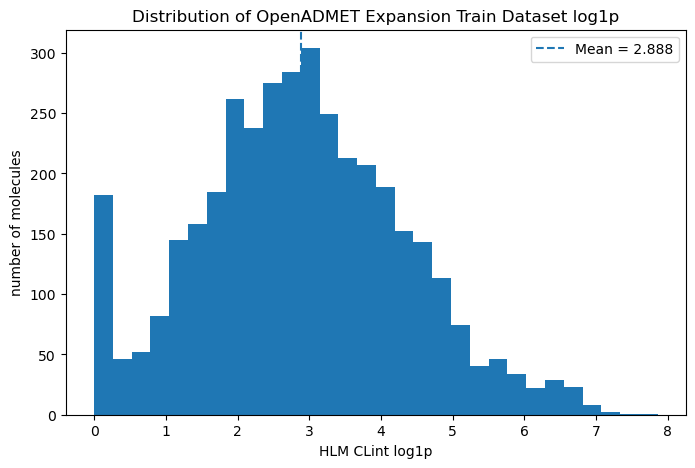

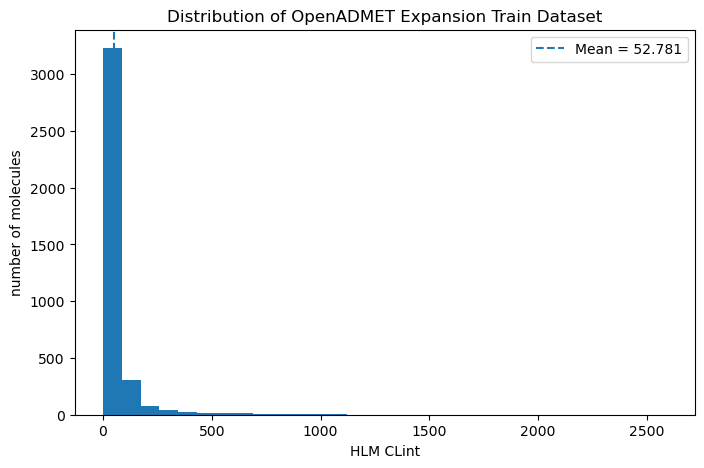

In [11]:
import matplotlib.pyplot as plt

# Mean values
mean_log1p = df_remove["hlm_value_unscaled_log1p"].mean()
mean_value = df_remove["hlm_value_scaled"].mean()

# Plot 1: distribution of hlm_value_log1p
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_unscaled_log1p"], bins=30)
plt.axvline(mean_log1p, linestyle="--", label=f"Mean = {mean_log1p:.3f}")
plt.xlabel("HLM CLint log1p")
plt.ylabel("number of molecules")
plt.title("Distribution of OpenADMET Expansion Train Dataset log1p")
plt.legend()
plt.show()

# Plot 2: distribution of hlm_value
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled"], bins=30)
plt.axvline(mean_value, linestyle="--", label=f"Mean = {mean_value:.3f}")
plt.xlabel("HLM CLint")
plt.ylabel("number of molecules")
plt.title("Distribution of OpenADMET Expansion Train Dataset")
plt.legend()
plt.show()

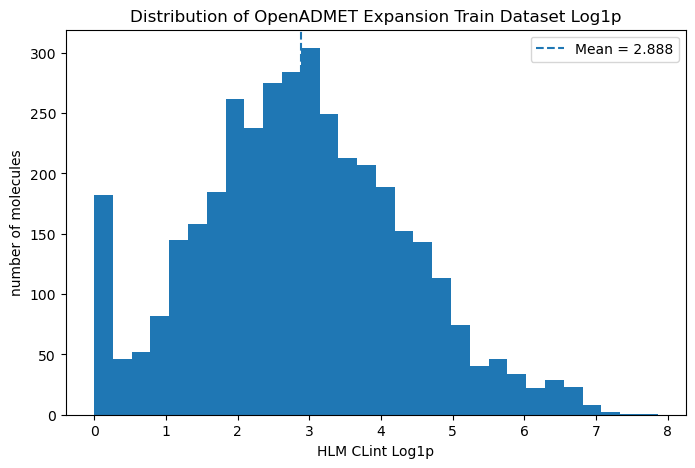

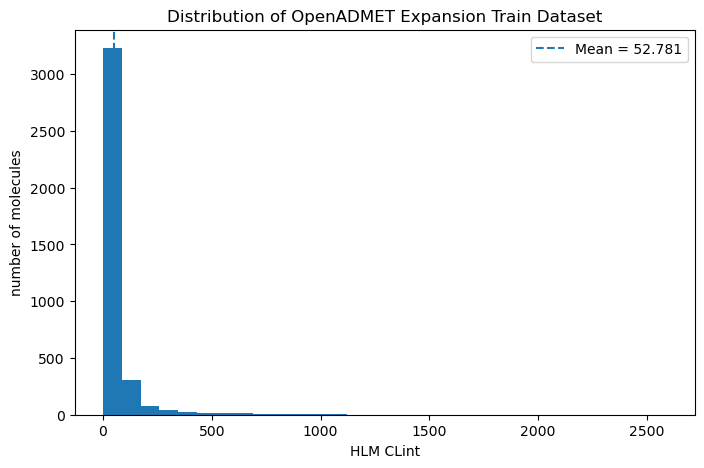

In [12]:
import matplotlib.pyplot as plt

# Mean values
mean_log1p = df_remove["hlm_value_scaled_log1p"].mean()
mean_value = df_remove["hlm_value_scaled"].mean()

# Plot 1: distribution of hlm_value_log1p
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled_log1p"], bins=30)
plt.axvline(mean_log1p, linestyle="--", label=f"Mean = {mean_log1p:.3f}")
plt.xlabel("HLM CLint Log1p")
plt.ylabel("number of molecules")
plt.title("Distribution of OpenADMET Expansion Train Dataset Log1p")
plt.legend()
plt.show()

# Plot 2: distribution of hlm_value
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled"], bins=30)
plt.axvline(mean_value, linestyle="--", label=f"Mean = {mean_value:.3f}")
plt.xlabel("HLM CLint")
plt.ylabel("number of molecules")
plt.title("Distribution of OpenADMET Expansion Train Dataset")
plt.legend()
plt.show()

In [13]:
df_remove["dataset"] = "openadmet_expansion_train"
df_remove["data_year"] = "2026"
df_remove.to_csv("adjusted_datasets/openadmet_expansion_train_adjusted.csv")